# Supplemental: DuckDB — SQL on your files (and your DataFrames)

**CS1090A / AC209A — Module 1** *(optional enrichment)*

Lecture 2's ecosystem map named three dialects of the same four ideas —
subset / aggregate / join / transform. You've practiced **pandas**; the *Polars
intro* shows the second dialect; this notebook is the third: **SQL**.

Why bother? Because the job market says so louder than any library trend: SQL
appears in roughly **half of data-analyst postings** — often ahead of Python —
and it's the shared language of every database, warehouse, and BI tool you'll
meet in industry.

**[DuckDB](https://duckdb.org)** makes SQL a zero-setup local tool: an embedded
analytics engine (think "SQLite for analytics") that queries Parquet/CSV files
and even in-memory DataFrames directly — no server, no ETL, `uv pip install duckdb`.

In [1]:
import duckdb
import numpy as np
import pandas as pd

print(f"duckdb {duckdb.__version__}, pandas {pd.__version__}")

duckdb 1.5.2, pandas 2.3.3


## 0. A toy dataset (same one as the Polars intro)

100,000 synthetic movie screenings — HW1's world, bigger.

In [2]:
rng = np.random.default_rng(1090)
n = 100_000

theaters = ["The Brattle", "Coolidge Corner", "Somerville Theatre", "Harvard Film Archive"]
genres = ["Drama", "Comedy", "Horror", "Sci-Fi", "Documentary"]

screenings = pd.DataFrame({
    "title": [f"Movie {i}" for i in rng.integers(0, 2_000, n)],
    "theater": rng.choice(theaters, n),
    "genre": rng.choice(genres, n),
    "year": rng.integers(1930, 2026, n),
    "runtime_min": rng.normal(110, 25, n).round().clip(45, 360),
    "price": rng.choice([9.0, 11.5, 13.0, 15.0], n),
})
screenings.head(3)

,title,theater,genre,year,runtime_min,price
0,Movie 576,The Brattle,Documentary,1942,101.0,9.0
1,Movie 1353,Somerville Theatre,Documentary,2025,96.0,15.0
2,Movie 960,The Brattle,Documentary,1988,90.0,13.0


## 1. Query a DataFrame — directly

DuckDB sees pandas DataFrames in your session as tables. No loading step: name
the variable in `FROM`.

In [3]:
duckdb.sql("""
    SELECT theater,
           count(*)          AS screenings,
           avg(runtime_min)  AS avg_runtime,
           sum(price)        AS revenue
    FROM screenings
    WHERE year > 1980
    GROUP BY theater
    ORDER BY revenue DESC
""")

┌──────────────────────┬────────────┬────────────────────┬──────────┐
│       theater        │ screenings │    avg_runtime     │ revenue  │
│       varchar        │   int64    │       double       │  double  │
├──────────────────────┼────────────┼────────────────────┼──────────┤
│ The Brattle          │      11898 │  110.0196671709531 │ 144279.0 │
│ Coolidge Corner      │      11746 │   110.373063170441 │ 142868.0 │
│ Harvard Film Archive │      11673 │ 110.19061081127388 │ 141013.0 │
│ Somerville Theatre   │      11521 │ 109.76321499869803 │ 139568.5 │
└──────────────────────┴────────────┴────────────────────┴──────────┘

Read that query against its pandas equivalent and the correspondence is nearly
word-for-word:

| Concept (Lec 2) | pandas | SQL |
|---|---|---|
| subset rows | `df[df.year > 1980]` | `WHERE year > 1980` |
| subset cols | `df[["theater", "price"]]` | `SELECT theater, price` |
| aggregate | `.groupby("theater").agg(...)` | `GROUP BY theater` + aggregates |
| join | `df.merge(other, on=...)` | `JOIN other USING (...)` |
| transform | `df.assign(hours=...)` | expressions in `SELECT` |
| sort | `.sort_values("revenue")` | `ORDER BY revenue` |

One mental model, two dialects. (Polars is a third — same table, same four verbs.)

## 2. SQL on *files*: skip the load step entirely

DuckDB's signature trick: `FROM 'file.parquet'` — query data at rest without
reading it into memory first. On big files this is dramatically faster and
lighter than `pd.read_parquet` → filter, because DuckDB reads **only the
columns and row groups the query needs** (recall the columnar-format discussion
from Lecture 2 — this is why Parquet matters).

In [4]:
import os
os.makedirs("data", exist_ok=True)
screenings.to_parquet("data/screenings.parquet")

duckdb.sql("""
    SELECT genre, count(*) AS n, round(avg(price), 2) AS avg_price
    FROM 'data/screenings.parquet'
    WHERE theater = 'The Brattle'
    GROUP BY genre
    ORDER BY n DESC
""")

┌─────────────┬───────┬───────────┐
│    genre    │   n   │ avg_price │
│   varchar   │ int64 │  double   │
├─────────────┼───────┼───────────┤
│ Comedy      │  5077 │     12.08 │
│ Drama       │  5068 │     12.08 │
│ Documentary │  4985 │      12.1 │
│ Horror      │  4972 │     12.18 │
│ Sci-Fi      │  4923 │     12.09 │
└─────────────┴───────┴───────────┘

Globs work too — `FROM 'data/*.parquet'` queries a whole directory of files as
one table. A folder of monthly exports becomes a database, with zero ETL.
(CSV works the same way: `FROM 'data/movies.csv'` — handy for your HW1
artifacts.)

## 3. Round-tripping: SQL when SQL is clearer, pandas when pandas is

`.df()` materializes any result as a pandas DataFrame, so you can drop into SQL
for one step of a pipeline and come right back. Under the hood both sides speak
Arrow, so the handoff is cheap.

Text(0.5, 1.0, 'Same pipeline, two dialects: SQL aggregate, pandas plot')

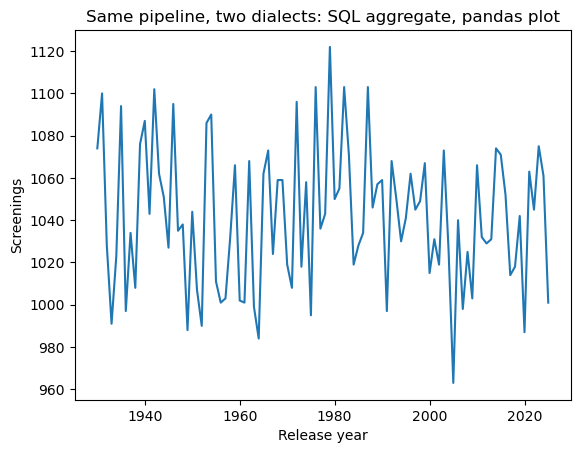

In [5]:
per_year = duckdb.sql("""
    SELECT year, count(*) AS screenings
    FROM 'data/screenings.parquet'
    GROUP BY year
""").df()                      # back to pandas...

# ...and onward with the tools you already know
ax = per_year.sort_values("year").plot(x="year", y="screenings", legend=False)
ax.set_xlabel("Release year")
ax.set_ylabel("Screenings")
ax.set_title("Same pipeline, two dialects: SQL aggregate, pandas plot")

## 4. When to reach for which

| Situation | Reasonable default |
|---|---|
| Interactive EDA, plotting, per-row Python logic | **pandas** |
| Aggregations/joins over big Parquet/CSV files | **DuckDB** |
| The query is easier to *say* in SQL (multi-join, window functions) | **DuckDB** |
| Handing analysis to analysts / BI tools / a warehouse | **SQL** (it transfers) |
| Sharing one file that any tool can read | **Parquet**, whoever writes it |

The point of this notebook is not "learn a fourth tool" — it's that the four
verbs you learned in Lecture 2 *are* the industry-standard query model, and
SQL is how most of the industry says them.

**Exercises:**
1. Rewrite HW1 Q4's screenings-per-theater-per-month table as one DuckDB query
   over your `data/movies_enriched.csv`. (Hint: `strftime`/`date_trunc`.)
2. Find the top-5 most-screened titles per theater with a window function
   (`row_number() OVER (PARTITION BY theater ORDER BY n DESC)`) — something
   genuinely awkward in pandas.
3. Time `pd.read_parquet(...)` + pandas groupby against the equivalent
   `duckdb.sql(...)` on `data/screenings.parquet`. Where does the gap come from?